In [21]:
# 1. Подключение и загрузка данных

import pandas as pd

data_path = r"C:\Users\Ekaterina\Desktop\таблицы маркетлейсов"

# Функция для загрузки таблицы из CSV
def load_table(table_name):
    print(f"Загружаем таблицу {table_name}...")

    file_path = os.path.join(data_path, f"{table_name}.csv")
    print(f"Путь: {file_path}")

    # Проверяем существование файла
    if not os.path.exists(file_path):
        print(f"❌ Файл не найден: {file_path}")
        return pd.DataFrame()

    df = pd.read_csv(file_path)
    print(f"Таблица {table_name} загружена, размер: {df.shape}")
    return df

# Список ключевых таблиц
tables = ['orders', 'order_items', 'products', 'users', 'categories', 'transactions', 'reviews']




# Загружаем все таблицы в словарь
data = {}
for tbl in tables:
    data[tbl] = load_table(tbl)




Загружаем таблицу orders...
Путь: C:\Users\Ekaterina\Desktop\таблицы маркетлейсов/orders.csv
Таблица orders загружена, размер: (100, 6)
Загружаем таблицу order_items...
Путь: C:\Users\Ekaterina\Desktop\таблицы маркетлейсов/order_items.csv
Таблица order_items загружена, размер: (300, 5)
Загружаем таблицу products...
Путь: C:\Users\Ekaterina\Desktop\таблицы маркетлейсов/products.csv
Таблица products загружена, размер: (50, 6)
Загружаем таблицу users...
Путь: C:\Users\Ekaterina\Desktop\таблицы маркетлейсов/users.csv
Таблица users загружена, размер: (50, 6)
Загружаем таблицу categories...
Путь: C:\Users\Ekaterina\Desktop\таблицы маркетлейсов/categories.csv
Таблица categories загружена, размер: (10, 4)
Загружаем таблицу transactions...
Путь: C:\Users\Ekaterina\Desktop\таблицы маркетлейсов/transactions.csv
Таблица transactions загружена, размер: (200, 6)
Загружаем таблицу reviews...
Путь: C:\Users\Ekaterina\Desktop\таблицы маркетлейсов/reviews.csv
Таблица reviews загружена, размер: (150, 7)


In [22]:
# 2. Предобработка

# Удаление дубликатов
total_dups = 0
for name, df in data.items():
    dups = df.duplicated().sum()
    total_dups += dups
    print(f'{name}: {dups} дубликатов')
    if dups > 0:
        df.drop_duplicates(inplace=True)

if total_dups == 0:
    print("во всех таблицах дубликаты не найдены!")

# Преобразование дат
data['orders']['order_date'] = pd.to_datetime(data['orders']['order_date'])
data['reviews']['review_date'] = pd.to_datetime(data['reviews']['review_date'])
data['transactions']['transaction_date'] = pd.to_datetime(data['transactions']['transaction_date'])
data['users']['registration_date'] = pd.to_datetime(data['users']['registration_date'])

# Исправление отрицательных цен в products
neg_prices = data['products'][data['products']['price'] < 0].shape[0]
if neg_prices > 0:
    data['products'].loc[data['products']['price'] < 0, 'price'] = 0
print(f'products: исправлено {neg_prices} отрицательных цен')

# Проверка пропусков
for name, df in data.items():
    print(f"\n{name} — пропущенные значения:")
    print(df.isna().sum())

# Категоризация рейтинга в reviews
def categorize_rating(r):
    if r >= 4.5:
        return 'High'
    elif r >= 4:
        return 'Medium'
    else:
        return 'Low'

data['reviews']['rating_category'] = data['reviews']['rating'].apply(categorize_rating)
print('reviews: добавлен столбец rating_category')



orders: 0 дубликатов
order_items: 0 дубликатов
products: 0 дубликатов
users: 0 дубликатов
categories: 0 дубликатов
transactions: 0 дубликатов
reviews: 0 дубликатов
во всех таблицах дубликаты не найдены!
products: исправлено 0 отрицательных цен

orders — пропущенные значения:
order_id          0
user_id           0
order_date        0
total_amount      0
status            0
payment_method    0
dtype: int64

order_items — пропущенные значения:
order_item_id     0
order_id          0
product_id        0
quantity          0
price_per_unit    0
dtype: int64

products — пропущенные значения:
product_id        0
product_name      0
category_id       0
price             0
stock_quantity    0
supplier          0
dtype: int64

users — пропущенные значения:
user_id              0
name                 0
email                0
registration_date    0
country              0
age                  0
dtype: int64

categories — пропущенные значения:
category_id           0
category_name         0
descript


Статистика по признакам: ['price', 'stock_quantity']


,price,stock_quantity
count,50.00000,50.000000
mean,2738.24200,430.040000
std,1475.16372,272.995923
min,186.54000,22.000000
25%,1542.56750,204.000000
50%,2679.20000,440.000000
75%,4068.62000,636.750000
max,4878.83000,986.000000


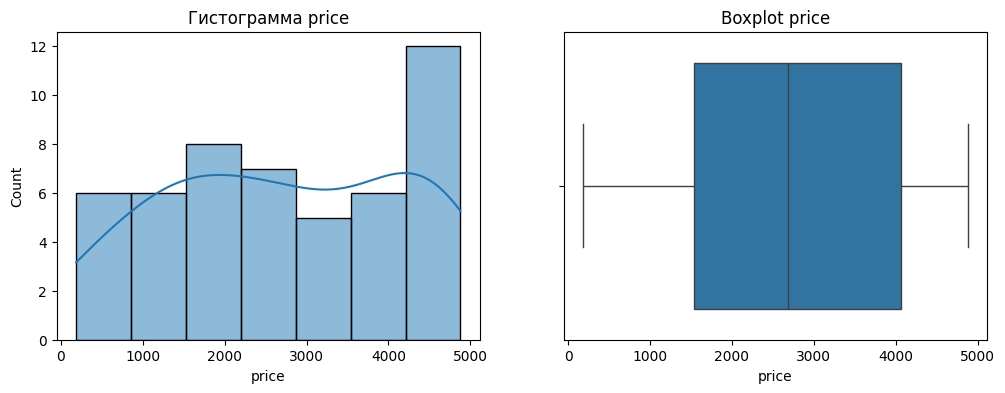

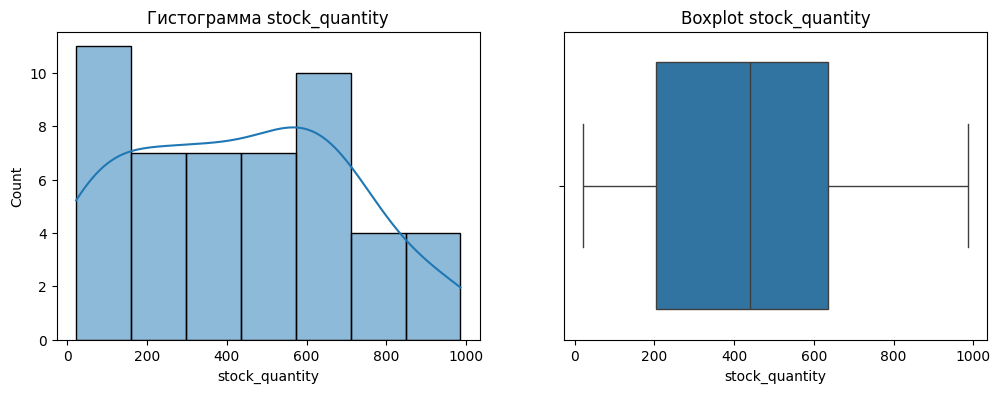


Корреляционная матрица:


,price,stock_quantity
price,1.000000,-0.061905
stock_quantity,-0.061905,1.000000


In [23]:
# 3. Исследовательский анализ

import matplotlib.pyplot as plt
import seaborn as sns

def eda(df, columns):
    print(f"\nСтатистика по признакам: {columns}")
    display(df[columns].describe())

    for col in columns:
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))

        sns.histplot(df[col].dropna(), kde=True, ax=axs[0])
        axs[0].set_title(f"Гистограмма {col}")

        sns.boxplot(x=df[col], ax=axs[1])
        axs[1].set_title(f"Boxplot {col}")

        plt.show()


# Пример для products
eda(data['products'], ['price', 'stock_quantity'])

# Корреляция
corr = data['products'][['price', 'stock_quantity']].corr()
print("\nКорреляционная матрица:")
display(corr)



In [24]:
# 4. Выгрузка обработанных данных

import os

output_dir = 'exported_csv'
os.makedirs(output_dir, exist_ok=True)

# Фильтрация по дате: только заказы с 01.01.2025 по 01.06.2025
orders_filtered = data['orders'][
    (data['orders']['order_date'] >= '2025-01-01') &
    (data['orders']['order_date'] <= '2025-06-01')
]

orders_path = os.path.join(output_dir, 'orders_filtered.csv')
orders_filtered.to_csv(orders_path, sep=";", index=False)

print(f"Таблица заказов успешно выгружена: {orders_path}")
print(f"Строк: {orders_filtered.shape[0]}, Колонок: {orders_filtered.shape[1]}")

Таблица заказов успешно выгружена: exported_csv/orders_filtered.csv
Строк: 100, Колонок: 6
